# Notebook 2 : Preprocessing, Feature Engineering & Modeling
### NutriScore Decoder | Open Food Facts Classification

--- 
**Dataset :** Open Food Facts — world.openfoodfacts.org  
**Goal :** Predict the NutriScore grade (A to E) from nutritional values

---

## Table of Contents
1. [Imports & Setup](#1)
2. [Data Loading](#2)
3. [Preprocessing](#3)
4. [Feature Engineering](#4)
5. [Train / Test Split & Feature Selection](#5)
6. [Modeling](#6)
7. [Models Comparison](#7)
8. [Hyperparameter Optimization](#8)
9. [Error Analysis](#9)
10. [SHAP Interpretability](#10)

---
<a id='1'></a>
## 1. Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from scipy.stats  import randint
# Create necessary directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)
#Plotting configuration
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize']   = (10, 5)
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'

# global constants
NUTRISCORE_COLORS = {'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 'd': '#EE8100', 'e': '#E63E11'}
GRADE_LABELS = ['A', 'B', 'C', 'D', 'E']
TARGET = 'nutriscore_grade'
VALID_GRADES = ['a', 'b', 'c', 'd', 'e']
RANDOM_STATE  = 42
print('Libraries loaded successfully ')

Libraries loaded successfully 


---
<a id='2'></a>
## 2. Data Loading
### Why we load this way
The full Open Food Facts dataset has more than 3 million rows (very large ~9GB) , so we can't just load everything at once .
To handle this we decided to read the file using **chunk-based loading** , it filters valid Nutriscore rows and  keeps only rows where all 8 core nutritional columns are filled in, and stop once we have enough data
### Why stratified sampling
After filtering, the data is imbalanced (some grades appear more than others)  
To avoid bias in the model, we use **stratified sampling** by selecting **5,000 samples per grade**, creating a balanced dataset of 25,000 rows
We chose 5,000 because it is below the smallest class size, so all grades can provide enough samples

In [2]:
"""CORE= ['energy_100g', 'fat_100g', 'saturated-fat_100g','carbohydrates_100g', 'sugars_100g', 'fiber_100g','proteins_100g', 'salt_100g']
N_PER_GRADE = 5000
chunks= []
for i, chunk in enumerate(pd.read_csv('data/en.openfoodfacts.org.products.csv.gz',
                                      sep='\t', low_memory=False, chunksize=50_000, on_bad_lines='skip')):
    chunk[TARGET] = chunk[TARGET].str.lower().str.strip()
    chunk = chunk[chunk[TARGET].isin(VALID_GRADES) & chunk[CORE].notna().all(axis=1)]
    chunks.append(chunk)
    total = sum(len(c) for c in chunks)
    if total >= 50_000:
        break

df_all = pd.concat(chunks, ignore_index=True)
print(f'Complete rows found : {len(df_all):,}')
print('Grade distribution before sampling:')
print(df_all[TARGET].value_counts().sort_index())

# stratified sample to ensure balanced representation of each grade
df = (df_all.groupby(TARGET)
      .apply(lambda x: x.sample(min(len(x), N_PER_GRADE), random_state=RANDOM_STATE))
      .reset_index(drop=True))
print(f'\nAfter sampling : {len(df):,} rows')
print(df[TARGET].value_counts().sort_index())
df.to_csv('data/sampled_data.csv', index=False)"""


"CORE= ['energy_100g', 'fat_100g', 'saturated-fat_100g','carbohydrates_100g', 'sugars_100g', 'fiber_100g','proteins_100g', 'salt_100g']\nN_PER_GRADE = 5000\nchunks= []\nfor i, chunk in enumerate(pd.read_csv('data/en.openfoodfacts.org.products.csv.gz',\n                                      sep='\t', low_memory=False, chunksize=50_000, on_bad_lines='skip')):\n    chunk[TARGET] = chunk[TARGET].str.lower().str.strip()\n    chunk = chunk[chunk[TARGET].isin(VALID_GRADES) & chunk[CORE].notna().all(axis=1)]\n    chunks.append(chunk)\n    total = sum(len(c) for c in chunks)\n    if total >= 50_000:\n        break\n\ndf_all = pd.concat(chunks, ignore_index=True)\nprint(f'Complete rows found : {len(df_all):,}')\nprint('Grade distribution before sampling:')\nprint(df_all[TARGET].value_counts().sort_index())\n\n# stratified sample to ensure balanced representation of each grade\ndf = (df_all.groupby(TARGET)\n      .apply(lambda x: x.sample(min(len(x), N_PER_GRADE), random_state=RANDOM_STATE))\n   

---
<a id='3'></a>
## 3. Data Preprocessing

Before training any model, the data needs to be cleaned and well prepared so we followed those steps : 

| Step | Action | Reason |
|------|---------|--------|
| 3.1 | Select core features | Keep only useful nutritional columns |
| 3.2 | Drop 100% empty columns | Remove empty columns |
| 3.3 | Fix physically impossible values | Replace aberrant values with NaN |
| 3.4 | Global median imputation | Fast, robust and no leakage |
| 3.5 | Encode target variable | Convert a/b/c/d/e → 0/1/2/3/4 |

### 3.1 Select Core Features
Our dataset has 209 columns most of them are metadata (URLs, timestamps, contributor names) that have nothing to do with nutrition in this case we kept only the `_100g` nutritional columns plus `nova_group` (food processing level) and `additives_n` (number of additives), which we identified in the EDA as being correlated with the NutriScore 
> **Note :** We **exclude `nutriscore_score`** from the features because this column is  
 the numeric score computed directly by **the official NutriScore algorithm** from the same nutrients we're using as input and including it wouuld cause data leakage



In [43]:
df=pd.read_csv('data/sampled_data.csv')
nutritional_cols= [c for c in df.columns if '_100g' in c and c != 'nutriscore_score']
non_nutritional_cols = [c for c in ['nova_group', 'additives_n'] if c in df.columns]
available = nutritional_cols + non_nutritional_cols
df = df[available + [TARGET]].copy()
print(f'Nutritional cols : {len(nutritional_cols)}')
print(f'Other cols : {non_nutritional_cols}')
print(f'Dataset shape : {df.shape}')

Nutritional cols : 121
Other cols : ['nova_group', 'additives_n']
Dataset shape : (25000, 124)


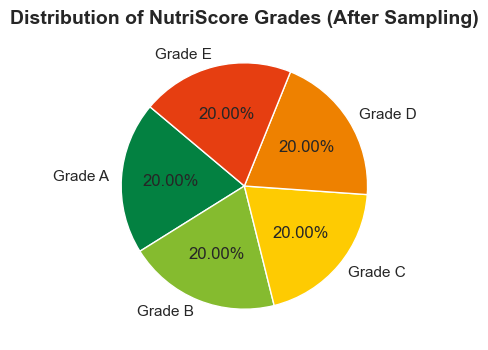

In [46]:
#Visualize the distribution of the target variable after sampling
grade_counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.pie(grade_counts, labels=[f'Grade {g.upper()}' for g in grade_counts.index], autopct='%1.2f%%', colors=[NUTRISCORE_COLORS[g] for g in grade_counts.index], startangle=140)
plt.title('Distribution of NutriScore Grades (After Sampling)', fontsize=14, fontweight='bold')
plt.show()


### 3.2 Drop 100% Empty Columns
Some columns are 100% empty (NaN), so we remove them because they add no value

In [4]:
cols_to_drop = df.columns[df.isnull().all()].tolist()
df= df.drop(columns=cols_to_drop)
nutritional_cols = [c for c in nutritional_cols if c in df.columns]
print(f'Dropped {len(cols_to_drop)} fully empty columns (new shape: {df.shape})')

Dropped 29 fully empty columns (new shape: (25000, 95))


### 3.3 Fix Physically impossible values
Open Food Facts is a **crowd-sourced dataset**, so some nutritional values are clearly wrong for example, a product showing 150g of fat per 100g of product, or a negative energy value
These are physically impossible so we replace them with NaN


In [5]:
n_fixed = 0
for col in nutritional_cols:
    neg  = (df[col] < 0).sum()
    df.loc[df[col] < 0, col] = np.nan
    n_fixed += neg
    if 'energy' not in col:
        over = (df[col] > 100).sum()
        df.loc[df[col] > 100, col] = np.nan
        n_fixed += over
    else:
        over = (df[col] > 3800).sum()
        df.loc[df[col] > 3800, col] = np.nan
        n_fixed += over
print(f'Impossible values replaced with NaN : {n_fixed}')

Impossible values replaced with NaN : 541


### 3.4 Handle Missing Values : Global Median Imputation
Even after keeping only the most complete rows, we still have missing values in many columns (1.6 million total) To solve that we tested 2 other approaches before setting on **Global Median Imputation** 
#### Why we chose median imputation ? and what we rejected ?
- **KNN Imputation** : theoretically the best because it fills missing values using the most similar products. We implemented it, but on 25,000 rows it took over 60 minutes to run => `too slow` 
- **Per-grade median imputation** : imputing the median of each grade separately. We tried this and got F1 = 1.0 on all models, which immediately told us something was wrong. The model wasn't learning nutrition it was detecting the imputation pattern itself => `Caused data leakage`
- **Global median imputation** : simple, fast (a few seconds), and completely leakage free. Each column gets replaced with its overall median, regardless of grade => `This is our final choice`

In [6]:
X_raw = df.drop(columns=[TARGET]).copy()
y_saved = df[TARGET].copy()
num_cols= X_raw.select_dtypes(include='number').columns.tolist()
print(f'Missing values before : {X_raw[num_cols].isnull().sum().sum():,}')
imp = SimpleImputer(strategy='median')
X_raw[num_cols] = imp.fit_transform(X_raw[num_cols])
df = X_raw.copy()
df[TARGET] = y_saved.values
print(f'Missing values after imputation : {df[num_cols].isnull().sum().sum()}')
print(f'Dataset shape : {df.shape}')

Missing values before : 1,618,086
Missing values after imputation : 0
Dataset shape : (25000, 95)


### 3.5 Encode Target Variable

As we know that machine learning models work with numbers, not letters that's why we mapped the NutriScore grades to integers: 
`A -> 0, B -> 1, C -> 2, D -> 3, E -> 4`

In [7]:

grade_to_int = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
df[TARGET]   = df[TARGET].map(grade_to_int)
dist  = df[TARGET].value_counts().sort_index()
ratio = dist.max() / dist.min()
print('Class distribution after encoding:')
for k, v in dist.items():
    print(f'  Grade {GRADE_LABELS[k]} ({k}): {v:>5,}  ({v/len(df)*100:.1f}%)')
print(f'\nImbalance ratio: {ratio:.2f}')

Class distribution after encoding:
  Grade A (0): 5,000  (20.0%)
  Grade B (1): 5,000  (20.0%)
  Grade C (2): 5,000  (20.0%)
  Grade D (3): 5,000  (20.0%)
  Grade E (4): 5,000  (20.0%)

Imbalance ratio: 1.00


### **Note: Why no IQR capping**
>
> At first, we tried using IQR outlier capping however, the results were very bad **( our F1-Macro dropped from 0.87 to 0.33)**
>
>We realized that this happens because nutritional data is naturally very spread out and not symmetric for example, a biscuit can normally have around 50g of sugar per 100g, while a salad may have only 2g. This big difference is not an error  it is actually useful information for the model
>
>By applying capping, we were reducing these differences, which removed important signals. As a result, the model could no longer clearly distinguish between good and bad nutritional grades
>


In [8]:
df.to_csv('data/data_cleaned.csv', index=False)
print(f'Saved to data_cleaned.csv  ({df.shape[0]:,} rows × {df.shape[1]} columns)')

Saved to data_cleaned.csv  (25,000 rows × 95 columns)


---
<a id='4'></a>
## 4. Feature Engineering

Raw nutritional columns give us individual nutrient quantities but theu don't capture the *relationships* between nutrients

We create 4 families of features:

| Family | What it captures |
|--------|------------------|
| Ratio features | Relative balance between nutrients |
| Composite scores | Overall good or bad nutrition |
| NutriScore approximation | We re-implement the official formula from raw values |
| Categorical bins | Fat and salt levels using official NutriScore thresholds |

In [9]:
df = pd.read_csv('data/data_cleaned.csv')
print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded : 25,000 rows × 95 columns


### 4.1 Ratio Features

In [10]:
eps = 1e-6
df['sugar_to_protein_ratio']= df['sugars_100g'] / (df['proteins_100g']  + eps)
df['fat_to_protein_ratio'] = df['fat_100g'] / (df['proteins_100g'] + eps)
df['fiber_sugar_balance'] = df['fiber_100g'] / (df['sugars_100g'] + eps)
df['saturated_fat_proportion'] = (df['saturated-fat_100g'] / (df['fat_100g'] + eps)).clip(0, 1)
df['fat_carb_ratio'] = df['fat_100g'] / (df['carbohydrates_100g'] + eps)
df['carb_sugar_ratio']= df['sugars_100g']/ (df['carbohydrates_100g'] + eps)
ratio_features = ['sugar_to_protein_ratio', 'fat_to_protein_ratio', 'fiber_sugar_balance',
    'saturated_fat_proportion', 'fat_carb_ratio', 'carb_sugar_ratio']
print('Ratio features :', ratio_features)

Ratio features : ['sugar_to_protein_ratio', 'fat_to_protein_ratio', 'fiber_sugar_balance', 'saturated_fat_proportion', 'fat_carb_ratio', 'carb_sugar_ratio']


### 4.2 Composite Scores

In [11]:
bad_cols  = [c for c in ['sugars_100g', 'fat_100g', 'salt_100g', 'saturated-fat_100g'] if c in df.columns]
good_cols = [c for c in ['proteins_100g', 'fiber_100g'] if c in df.columns]
df['bad_nutrients_score']  = df[bad_cols].sum(axis=1)
df['good_nutrients_score'] = df[good_cols].sum(axis=1)
df['health_balance'] = df['good_nutrients_score'] - df['bad_nutrients_score']
df['total_macros'] = df['fat_100g'] + df['proteins_100g'] + df['carbohydrates_100g']
composite_base = ['bad_nutrients_score', 'good_nutrients_score', 'health_balance', 'total_macros']
print('Composite features :', composite_base)

Composite features : ['bad_nutrients_score', 'good_nutrients_score', 'health_balance', 'total_macros']


### 4.3 NutriScore approximation (our most important feature)
The NutriScore algorithm (from Santé Publique France) calculates a numeric score from nutrients and then assigns a letter grade. Instead of using the provided ``nutriscore_score``, we **re-created the formula** ourselves using the raw nutrient columns
> **Why we didn't use `nutriscore_score` directly ?** because that would give the model the answer including it directly would mean that the model learns nothing . By building it ourselves, the model actually learns patterns from the nutrients


In [12]:
# negative points = bad nutrients
neg_energy_pts = (df['energy_100g'] / 335).clip(0, 10)
neg_satfat_pts = (df['saturated-fat_100g'] / 1.0).clip(0, 10)
neg_sugar_pts = (df['sugars_100g'] / 4.5).clip(0, 10)
neg_salt_pts = (df['salt_100g'] / 0.45).clip(0, 10)
df['negative_points'] = neg_energy_pts + neg_satfat_pts + neg_sugar_pts + neg_salt_pts
# positive points = good nutrients
pos_protein_pts = (df['proteins_100g'] / 1.6).clip(0, 5)
pos_fiber_pts = (df['fiber_100g'] / 0.9).clip(0, 5)
df['positive_points'] = pos_protein_pts + pos_fiber_pts
# official NutriScore approximation 
df['approx_nutriscore'] = df['negative_points'] - df['positive_points']
nutriscore_features = ['negative_points', 'positive_points', 'approx_nutriscore']
print('NutriScore features :', nutriscore_features)

NutriScore features : ['negative_points', 'positive_points', 'approx_nutriscore']


### 4.4 Categorical bins 

In [13]:
# categorical bins using official NutriScore thresholds
df['fat_category']  = pd.cut(df['fat_100g'],  bins=[-np.inf, 3, 17.5, np.inf], labels=[0,1,2]).astype(int)
df['salt_category'] = pd.cut(df['salt_100g'], bins=[-np.inf, 0.3, 1.5, np.inf], labels=[0,1,2]).astype(int)
bin_features = ['fat_category', 'salt_category']
engineered_features = ratio_features + nutriscore_features + composite_base + bin_features
print(f'Total engineered features : {len(engineered_features)}')
print(f'Dataset shape after FE : {df.shape}')

Total engineered features : 15
Dataset shape after FE : (25000, 110)


In [14]:
# validate engineered features by checking their correlation with the target
print('Correlations with target (top engineered) :')
eng_corr = (df[engineered_features]
            .corrwith(pd.Series(df[TARGET], index=df.index))
            .dropna().sort_values(key=abs, ascending=False))
print(eng_corr.round(4).to_string())

Correlations with target (top engineered) :
approx_nutriscore           0.7898
negative_points             0.7666
bad_nutrients_score         0.6273
health_balance             -0.6132
fat_category                0.4940
salt_category               0.4455
total_macros                0.4278
saturated_fat_proportion    0.2656
sugar_to_protein_ratio      0.1136
positive_points            -0.0752
fiber_sugar_balance        -0.0658
good_nutrients_score       -0.0523
fat_carb_ratio              0.0241
fat_to_protein_ratio        0.0228
carb_sugar_ratio           -0.0063


The validation shows that our feature engineering really works : 
- `approx_nutriscore` -> 0.79 -> Very Strong
- `negative_points` -> 0.77 -> Very Strong
- `bad_nutrients_score` -> 0.63 -> Moderatly Strong
- `health_balance` -> -0.61 -> moderately strong, but negative



## Feature Selection
We manually selected features based of their correlation with the target  If we used all 110 columns they will add noise and make the model worse 

**Note:** From the visualization, we noticed some features provide the same information, like `energy_100g`, `energy-kj_100g`, and `energy-kcal_100g`so we kept only one of them.

C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


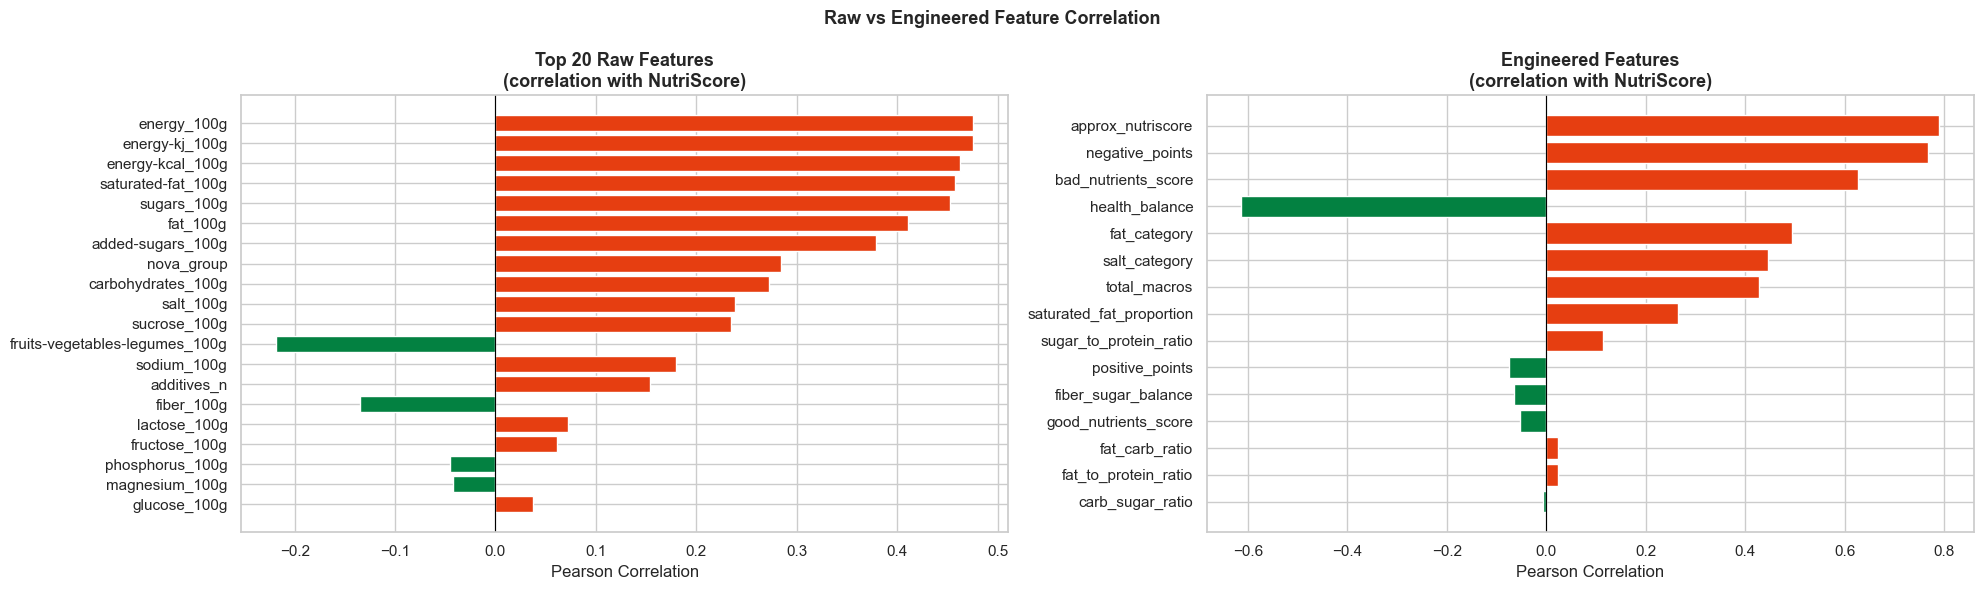

In [15]:
# Visualize Top 20 raw features vs  engineered features by absolute correlation with target
raw_cols = [c for c in df.columns if c not in engineered_features and c != TARGET]
raw_corr = (df[raw_cols].corrwith(pd.Series(df[TARGET], index=df.index)).dropna().sort_values(key=abs, ascending=False).head(20))
eng_corr = (df[engineered_features].corrwith(pd.Series(df[TARGET], index=df.index)).dropna().sort_values(key=abs, ascending=False).head(20))
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, corr, title in zip(axes,[raw_corr, eng_corr],['Top 20 Raw Features', 'Engineered Features']):
    colors = ['#E63E11' if v > 0 else '#038141' for v in corr.values]
    ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title}\n(correlation with NutriScore)')
    ax.set_xlabel('Pearson Correlation')
plt.suptitle('Raw vs Engineered Feature Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_correlation.png', dpi=150)
plt.show()


In [16]:
FINAL_FEATURES=['energy_100g','saturated-fat_100g', 'sugars_100g', 'fat_100g', 
  'nova_group', 'carbohydrates_100g', 'salt_100g','fruits-vegetables-legumes_100g',
  'additives_n', 'fiber_100g', 'lactose_100g', 'phosphorus_100g', 'magnesium_100g',  'approx_nutriscore',
  'negative_points', 'bad_nutrients_score', 'health_balance', 'fat_category','salt_category', 'total_macros', 'sugar_to_protein_ratio',
  'positive_points', 'fiber_sugar_balance', 'good_nutrients_score', 'fat_carb_ratio', 'fat_to_protein_ratio' , 'proteins_100g']
print(f'Final features selected for modeling : {len(FINAL_FEATURES)}')

Final features selected for modeling : 27


---
<a id='5'></a>
## 5. Train / Test

We divide the dataset into a training set (80%) and a test set (20%) before performing feature selection or model training. Doing the split first ensures that the test set remains completely unseen, providing a fair and unbiased evaluation of the model’s performance

In [ ]:
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df.columns]
X = df[FINAL_FEATURES]
y = df[TARGET]

# split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# scale on train only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f'Train : {X_train.shape[0]:,} samples (80%)')
print(f'Test: {X_test.shape[0]:,}  samples (20%)')
#Print class distribution in train and test sets to verify stratification
for name, y_s in [('Train', y_train), ('Test', y_test)]:
    pcts = (y_s.value_counts(normalize=True).sort_index() * 100).round(1)
    print(f'{name} : { {GRADE_LABELS[k]: f"{v}%" for k,v in pcts.items()} }')

joblib.dump(FINAL_FEATURES, 'models/feature_names.pkl')

Train : 20,000 samples (80%)
Test: 5,000  samples (20%)
Train : {'A': '20.0%', 'B': '20.0%', 'C': '20.0%', 'D': '20.0%', 'E': '20.0%'}
Test : {'A': '20.0%', 'B': '20.0%', 'C': '20.0%', 'D': '20.0%', 'E': '20.0%'}


['models/feature_names.pkl']

---
<a id='6'></a>
## 6. Modeling

We train 3 classifiers representing fundamentally different approaches to learning. The goal is not just to find the best model, but to understand *why* each one performs the way it does.

| Model | Type | Core idea | Why we include it |
|-------|------|-----------|-------------------|
| Logistic Regression | Linear | Tries to separate classes using a straight-line combination of the features |Used as a simple starting point to see if a linear approach is enough or if the problem is more complex |
| Random Forest | Ensemble (Bagging) | Builds many decision trees on different random samples and combines their votes | Used because it can capture non-linear patterns and is usually strong and stable on tabular data |
| XGBoost | Ensemble (Boosting) | Builds trees sequentially, each correcting the previous | Included because it is one of the most powerful models for structured data and often gives the best results |


### 6.1 Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
acc_lr= accuracy_score(y_test, y_pred_lr)
f1_lr= f1_score(y_test, y_pred_lr, average='macro')
print('Model 1 : Logistic Regression')
print(f'Accuracy : {acc_lr:.4f}  ({acc_lr*100:.1f}%)')
print(f'F1-Macro : {f1_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=GRADE_LABELS))

Model 1 : Logistic Regression
Accuracy : 0.7292  (72.9%)
F1-Macro : 0.7303

              precision    recall  f1-score   support

           A       0.79      0.74      0.76      1000
           B       0.62      0.69      0.65      1000
           C       0.70      0.72      0.71      1000
           D       0.75      0.69      0.72      1000
           E       0.82      0.81      0.81      1000

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



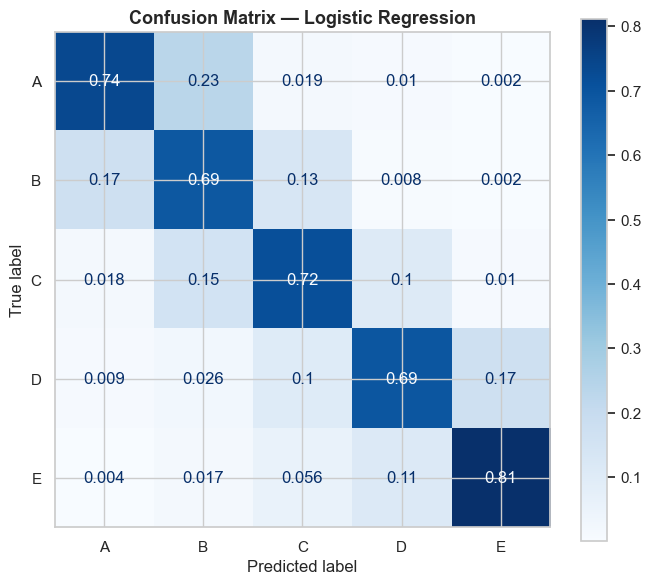

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr, normalize='true'),
                       display_labels=GRADE_LABELS).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('plots/cm_logreg.png', dpi=150)
plt.show()

### 6.2 Random Forest

In [20]:
rf_model = RandomForestClassifier( n_estimators=200, max_depth=15, min_samples_leaf=5,
                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print('Model 2 : Random Forest')
print(f'Accuracy : {acc_rf:.4f}  ({acc_rf*100:.1f}%)')
print(f'F1-Macro : {f1_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=GRADE_LABELS))

Model 2 : Random Forest
Accuracy : 0.8776  (87.8%)
F1-Macro : 0.8780

              precision    recall  f1-score   support

           A       0.89      0.88      0.88      1000
           B       0.79      0.86      0.82      1000
           C       0.90      0.83      0.86      1000
           D       0.89      0.90      0.90      1000
           E       0.93      0.92      0.93      1000

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



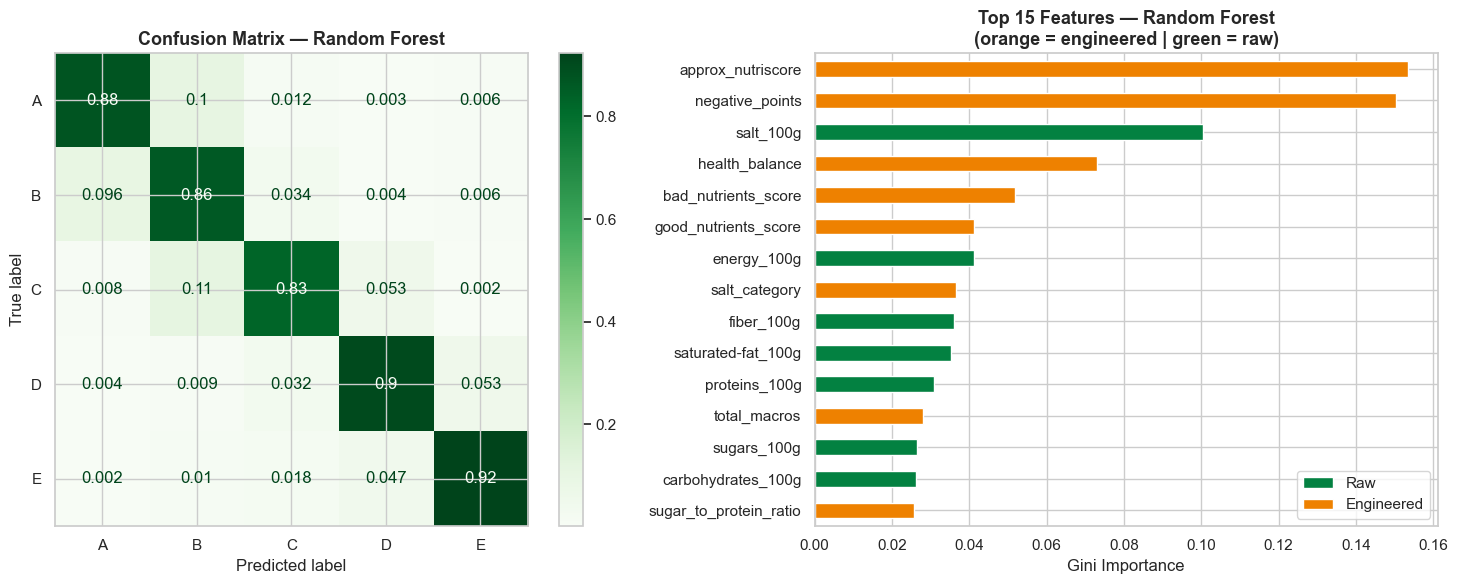

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf, normalize='true'),
                       display_labels=GRADE_LABELS).plot(ax=axes[0], cmap='Greens')
axes[0].set_title('Confusion Matrix — Random Forest')

imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
c   = ['#EE8100' if f in engineered_features else '#038141' for f in imp.index]
imp.plot(kind='barh', ax=axes[1], color=c)
axes[1].set_xlabel('Gini Importance')
axes[1].set_title('Top 15 Features — Random Forest\n(orange = engineered | green = raw)')
axes[1].legend(handles=[mpatches.Patch(facecolor='#038141', label='Raw'),
                         mpatches.Patch(facecolor='#EE8100', label='Engineered')], loc='lower right')
plt.tight_layout()
plt.savefig('plots/rf_results.png', dpi=150)
plt.show()

### 6.3 XGBoost

In [22]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = XGBClassifier(
    n_estimators= 300,
    max_depth= 4,  
    learning_rate = 0.05,
    subsample= 0.8,
    colsample_bytree= 0.8,   
    random_state= RANDOM_STATE)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

print('Model 3 : XGBoost')
print(f'Accuracy : {acc_xgb:.4f}  ({acc_xgb*100:.1f}%)')
print(f'F1-Macro : {f1_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=GRADE_LABELS))

Model 3 : XGBoost
Accuracy : 0.8776  (87.8%)
F1-Macro : 0.8780

              precision    recall  f1-score   support

           A       0.90      0.87      0.89      1000
           B       0.79      0.85      0.82      1000
           C       0.89      0.84      0.86      1000
           D       0.90      0.90      0.90      1000
           E       0.92      0.92      0.92      1000

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



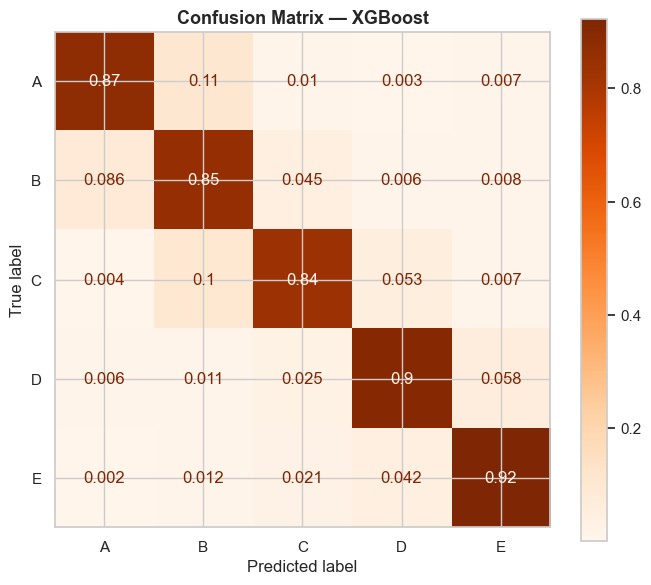

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb, normalize='true'),
                       display_labels=GRADE_LABELS).plot(ax=ax, cmap='Oranges')
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('plots/cm_xgb.png', dpi=150)
plt.show()

---
<a id='7'></a>
## 7. Models Comparison

In [24]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': acc_lr,  'F1-Macro': f1_lr},
    {'Model': 'Random Forest','Accuracy': acc_rf,  'F1-Macro': f1_rf},
    {'Model': 'XGBoost','Accuracy': acc_xgb, 'F1-Macro': f1_xgb},
]).set_index('Model')

print('Models Comparison:')
print(results.round(4).to_string())
print(f'\nBest model (F1-Macro): {results["F1-Macro"].idxmax()}')

Models Comparison:
                     Accuracy  F1-Macro
Model                                  
Logistic Regression    0.7292    0.7303
Random Forest          0.8776    0.8780
XGBoost                0.8776    0.8780

Best model (F1-Macro): Random Forest


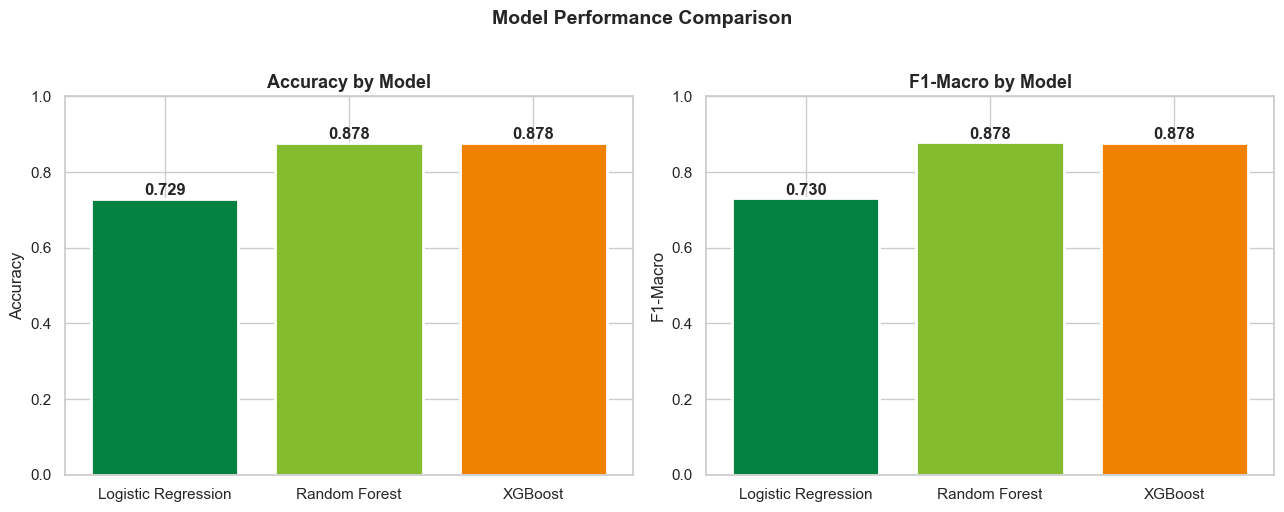

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#038141', '#85BB2F', '#EE8100']

for ax, metric in zip(axes, ['Accuracy', 'F1-Macro']):
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor='white', linewidth=2)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric} by Model')
    ax.set_ylabel(metric)
    for bar, v in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150)
plt.show()

Random Forest and XGBoost are equal. The gap over Logistic Regression (+15 points) confirms that the NutriScore prediction problem is non-linear so a simple linear boundary is not enough to separate the 5 grades well

---
<a id='8'></a>
## 8. Hyperparameter Optimization

Random Forest and XGBoost have similar raw performance, but XGBoost gives more flexibility and has a higher potential for improvement thanks to its boosting approach and advanced regularization options and also it has more hyperparameters to tune including regularization terms (`reg_alpha` and `reg_lambda`) tthat directly control overfitting yhat's why we choose to tune XGBoost rather than Random Forest

### Why RandomizedSearchCV instead of GridSearchCV

GridSearchCV tests every possible combination of parameters. With 7 hyperparameters and 3-4 values each, that would be thousands of combinations × 5 folds = tens of thousands of model fits and this would take hours RandomizedSearchCV samples 30 random combinations instead  it covers the parameter space much faster and consistently finds near-optimal solutions



In [26]:

param_distributions = {
    'n_estimators': randint(100, 300),
    'learning_rate' : [0.01, 0.05, 0.1],
    'max_depth' : [3, 4, 5],        
    'subsample' : [0.6, 0.7, 0.8],    
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha' : [0.5, 1.0, 2.0],   
    'reg_lambda' : [1.0, 2.0, 5.0],  
    'min_child_weight': [3, 5, 10],    
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    estimator = XGBClassifier(random_state=RANDOM_STATE, verbosity=0),
    param_distributions = param_distributions,
    n_iter= 30,
    cv = cv_strategy,
    scoring = 'f1_macro',
    n_jobs = -1,
    verbose = 1
)
search.fit(X_train, y_train, sample_weight=sample_weights)
print(f'Best CV F1-Macro : {search.best_score_:.4f}')
for k, v in search.best_params_.items():
    print(f'  {k:<22} : {v}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV F1-Macro : 0.8750
  colsample_bytree       : 0.6
  learning_rate          : 0.1
  max_depth              : 5
  min_child_weight       : 10
  n_estimators           : 189
  reg_alpha              : 1.0
  reg_lambda             : 5.0
  subsample              : 0.6


In [ ]:
best_model  = search.best_estimator_
y_pred_best = best_model.predict(X_test)
acc_best= accuracy_score(y_test, y_pred_best)
f1_best= f1_score(y_test, y_pred_best, average='macro')
print('Tuned XGBoost — Test Set Results')
print(f'Accuracy : {acc_best:.4f}  ({acc_best*100:.1f}%)')
print(f'F1-Macro : {f1_best:.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=GRADE_LABELS))

Tuned XGBoost — Test Set Results
Accuracy : 0.8842  (88.4%)
F1-Macro : 0.8846

              precision    recall  f1-score   support

           A       0.91      0.88      0.89      1000
           B       0.80      0.87      0.83      1000
           C       0.89      0.84      0.87      1000
           D       0.90      0.91      0.90      1000
           E       0.93      0.93      0.93      1000

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



### 8.1 Cross-Validation : Robustness Check

A single train/test split can sometimes be lucky. We run 5-fold CV to confirm the model is stable across different splits and not overfitting.

In [28]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-Fold CV Results (F1-Macro on training set):')
print()
cv_results = []
for name, model, X_data in [
    ('Logistic Regression', lr,X_train_sc),
    ('Random Forest', rf_model,   X_train.values),
    ('XGBoost', xgb_model,  X_train.values),
    ('Tuned XGBoost', best_model, X_train.values),]:
    scores = cross_val_score(model, X_data, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    cv_results.append({'Model': name, 'CV': scores.mean(), 'Std': scores.std()})
    print(f'  {name:<25} F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}')

cv_f1  = cv_results[-1]['CV']
cv_std = cv_results[-1]['Std']
gap = abs(cv_f1 - f1_best)
print(f'\nTuned XGBoost : Test  : {f1_best:.4f}')
print(f'Tuned XGBoost : CV : {cv_f1:.4f}')
print(f'Gap: {gap:.4f} => {" No overfitting" if gap < 0.03 else "Check overfitting"}')

5-Fold CV Results (F1-Macro on training set):

  Logistic Regression       F1-Macro: 0.7322 ± 0.0048
  Random Forest             F1-Macro: 0.8659 ± 0.0068
  XGBoost                   F1-Macro: 0.8692 ± 0.0078
  Tuned XGBoost             F1-Macro: 0.8750 ± 0.0074

Tuned XGBoost : Test  : 0.8846
Tuned XGBoost : CV : 0.8750
Gap: 0.0097 =>  No overfitting


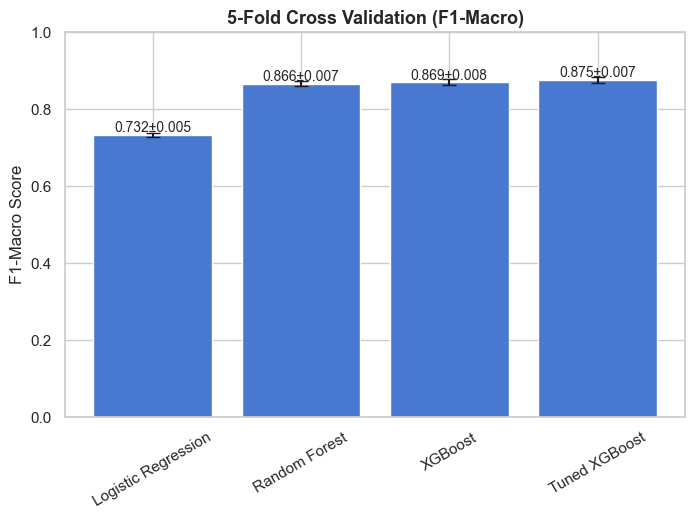

In [ ]:

models = [r['Model'] for r in cv_results]
means = [r['CV'] for r in cv_results]
stds  = [r['Std'] for r in cv_results]

plt.figure(figsize=(8,5))

bars = plt.bar(models, means, yerr=stds, capsize=5)
for bar, mean, std in zip(bars, means, stds):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{mean:.3f}±{std:.3f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("5-Fold Cross Validation (F1-Macro)")
plt.ylabel("F1-Macro Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

---
<a id='9'></a>
## 9. Error Analysis

We go beyond the global metrics to evaluate our model that 's why we need to understand :
1. Which grades are hardest to classify correctly?
2. When the model is wrong, how far off is it?
3. Is the model learning from nutritionally meaningful signals?

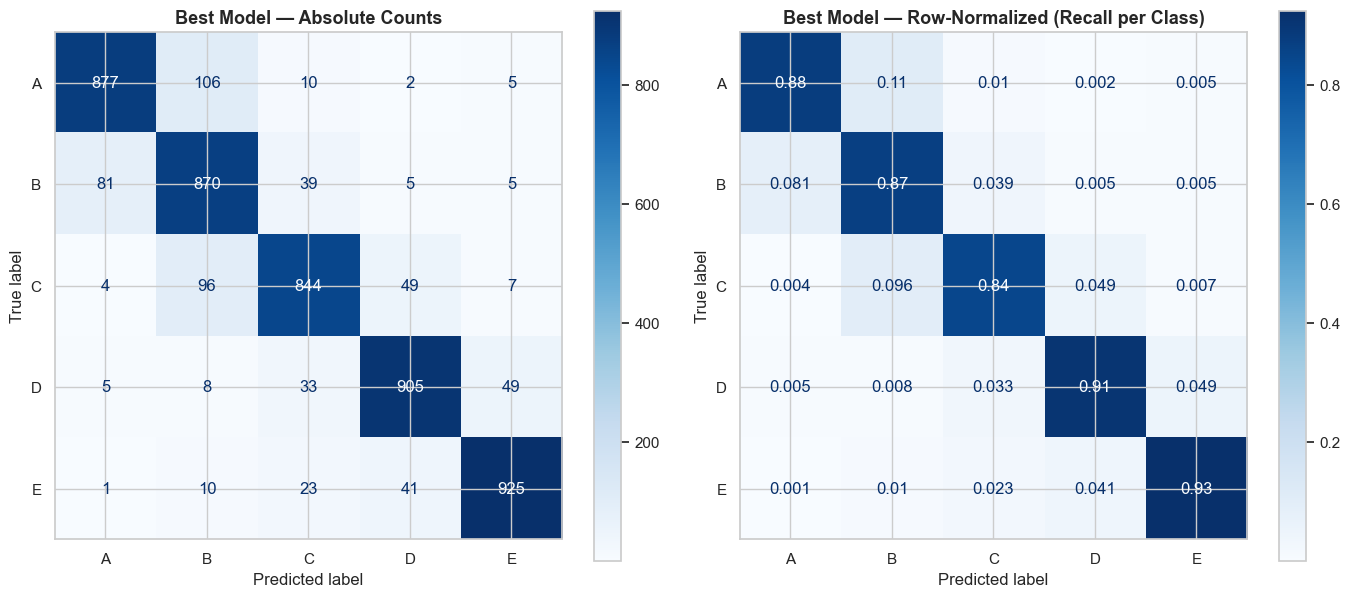

Recall per class:
  Grade A: 87.7% correctly classified
  Grade B: 87.0% correctly classified
  Grade C: 84.4% correctly classified
  Grade D: 90.5% correctly classified
  Grade E: 92.5% correctly classified


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),
                       display_labels=GRADE_LABELS).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Best Model — Absolute Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best, normalize='true'),
                       display_labels=GRADE_LABELS).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Best Model — Row-Normalized (Recall per Class)')
plt.tight_layout()
plt.savefig('plots/cm_best.png', dpi=150)
plt.show()
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
print('Recall per class:')
for i, g in enumerate(GRADE_LABELS):
    print(f'  Grade {g}: {cm_norm[i,i]*100:.1f}% correctly classified')

In [30]:
err = pd.DataFrame({ 'true': y_test.values,'pred': y_pred_best,'correct': y_test.values == y_pred_best })
err['true_label'] = err['true'].map(dict(enumerate(GRADE_LABELS)))
err['pred_label'] = err['pred'].map(dict(enumerate(GRADE_LABELS)))

print('Error rate per class:')
error_rates = err.groupby('true_label')['correct'].apply(lambda x: 1 - x.mean())
for g, r in error_rates.items():
    print(f'  Grade {g} : {r*100:5.1f}% ')


Error rate per class:
  Grade A :  12.3% 
  Grade B :  13.0% 
  Grade C :  15.6% 
  Grade D :   9.5% 
  Grade E :   7.5% 


In [31]:
err= X_test[y_test != y_pred_best].copy()
err['actual'] = y_test[y_test != y_pred_best]
err['predicted'] = y_pred_best[y_test != y_pred_best]
print(f'Total misclassified samples: {len(err):,}')
print("Some examples of misclassified products:")
print(err.head())
#Analyze which features contributed most to the misclassifications by comparing average feature values of misclassified vs correctly classified samples
correct = X_test[y_test == y_pred_best].copy()
comparison = pd.DataFrame({
     'Erreurs': err.drop(['actual','predicted'], axis=1).mean(),
    'Correctes': correct.mean()
})
print(comparison.sort_values('Erreurs', key=abs, ascending=False).head(10))

Total misclassified samples: 579
Some examples of misclassified products:
       energy_100g  saturated-fat_100g  sugars_100g    fat_100g  nova_group  \
13761  1881.428571            1.428571         20.0   12.857143         4.0   
11023   404.430000            0.000000         14.1    0.000000         4.0   
18097   321.000000            1.000000         10.0    1.700000         3.0   
18346  3700.000000           46.150000          0.0  100.000000         4.0   
1139    785.400000            1.000000          5.0    8.000000         4.0   

       carbohydrates_100g  salt_100g  fruits-vegetables-legumes_100g  \
13761           71.428571    0.50000                        6.152344   
11023           14.540000    0.21336                        0.000000   
18097           11.000000    0.01000                        0.000000   
18346            0.000000    0.00000                        0.000000   
1139            22.100000    0.00000                       23.875000   

       additives_n

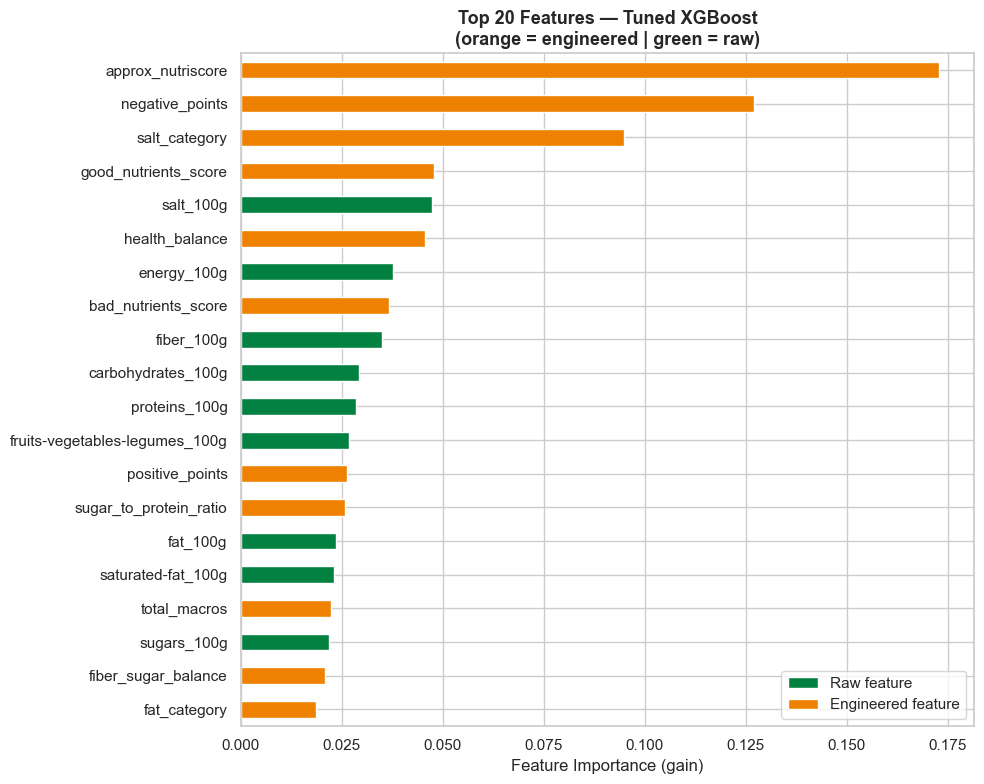

In [32]:
# feature importance of the best model
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
c = ['#EE8100' if f in engineered_features else '#038141' for f in imp.index]
imp.plot(kind='barh', ax=ax, color=c)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Features — Tuned XGBoost\n(orange = engineered | green = raw)')
ax.legend(handles=[mpatches.Patch(facecolor='#038141', label='Raw feature'),
                   mpatches.Patch(facecolor='#EE8100', label='Engineered feature')], loc='lower right')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150)
plt.show()

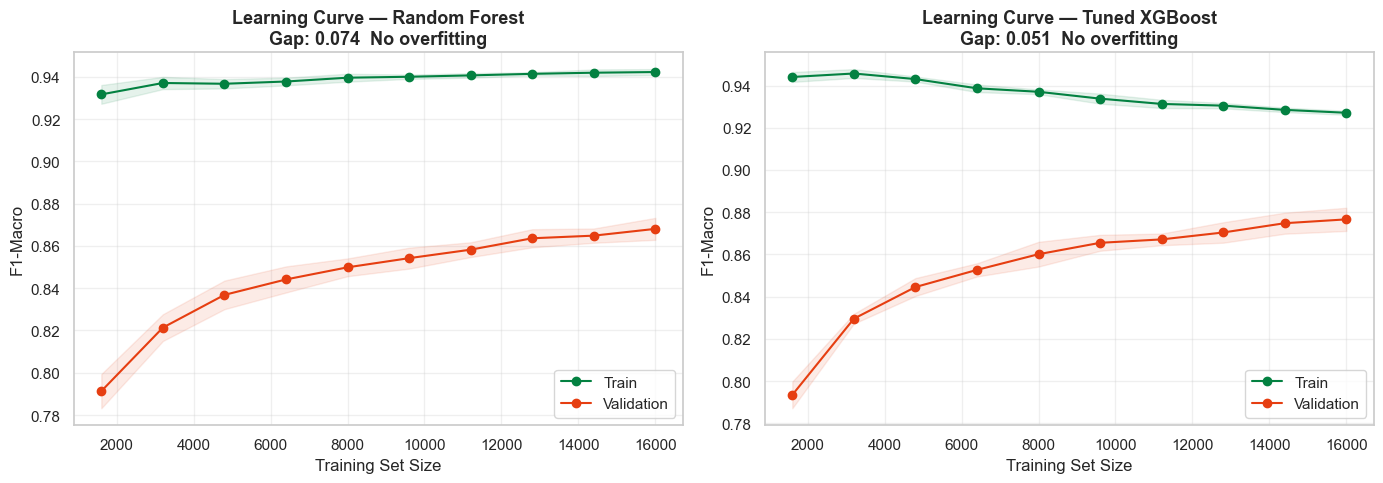

In [33]:
# learning curves — check for overfitting visually
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, X_data) in zip(axes, [
    ('Random Forest', rf_model,   X_train),
    ('Tuned XGBoost', best_model, X_train),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_data, y_train,
        cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#038141', label='Train')
    ax.fill_between(train_sizes,
                    train_mean - train_scores.std(axis=1),
                    train_mean + train_scores.std(axis=1), alpha=0.1, color='#038141')
    ax.plot(train_sizes, val_mean,   'o-', color='#E63E11', label='Validation')
    ax.fill_between(train_sizes,
                    val_mean - val_scores.std(axis=1),
                    val_mean + val_scores.std(axis=1), alpha=0.1, color='#E63E11')

    gap = train_mean[-1] - val_mean[-1]
    status = 'No overfitting' if gap < 0.1 else 'Overfitting'
    ax.set_title(f'Learning Curve — {name}\nGap: {gap:.3f}  {status}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1-Macro')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/learning_curves.png', dpi=150)
plt.show()

---
<a id='10'></a>
## 10. SHAP Interpretability

### Why SHAP matters

A model that scores 88% F1 is useful, but a model that can *explain its decisions* is trustworthy. SHAP (SHapley Additive exPlanations) is a framework based on game theory that assigns each feature a contribution value for each individual prediction.

Unlike standard feature importance (which tells us the global average impact), SHAP tells us:
- **How much** each feature contributes to a specific prediction
- **In which direction** — does it push toward grade A or toward grade E?
- **For each sample individually** — not just a global average

This is especially important in a nutritional context — if a doctor or a consumer asks "why was this product graded D?", SHAP lets us answer precisely.

100%|===================| 2499/2500 [01:36<00:00]        

SHAP values computed for 500 products
Shape : (500, 27, 5)  (samples × features × classes)


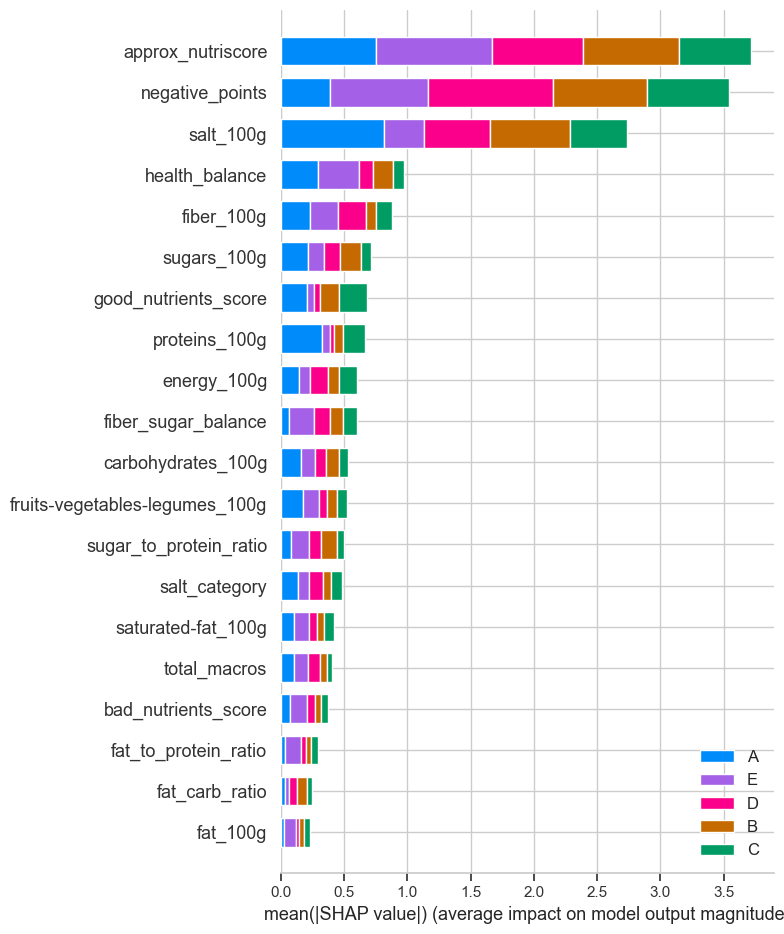

In [34]:
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.Explainer(best_model, X_train)
shap_values= explainer(X_sample)
print(f'SHAP values computed for {X_sample.shape[0]} products')
print(f'Shape : {shap_values.values.shape}  (samples × features × classes)')
shap.summary_plot(shap_values, X_sample, feature_names=X_train.columns, class_names=GRADE_LABELS, show=False)
plt.tight_layout()
plt.savefig('plots/shap_summary.png', dpi=150)
plt.show()

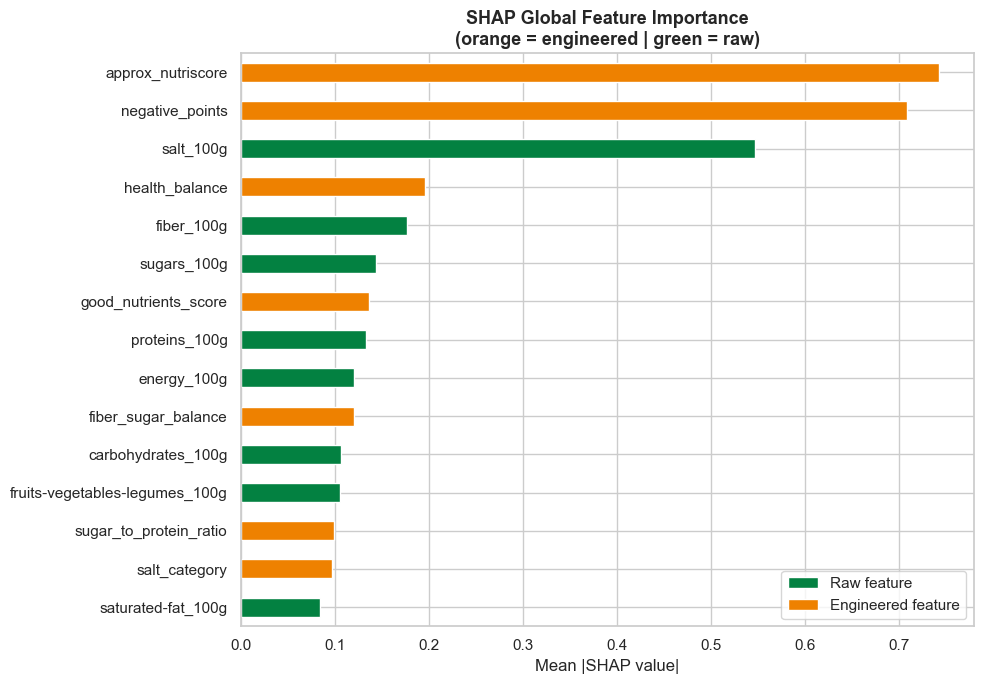

In [35]:
# global importance
shap_abs_mean = np.abs(shap_values.values).mean(axis=0).mean(axis=1)  
shap_imp = (pd.Series(shap_abs_mean, index=X_sample.columns)
            .sort_values(ascending=True).tail(15))

fig, ax = plt.subplots(figsize=(10, 7))
c = ['#EE8100' if f in engineered_features else '#038141' for f in shap_imp.index]
shap_imp.plot(kind='barh', ax=ax, color=c)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Global Feature Importance\n(orange = engineered | green = raw)')
ax.legend(handles=[mpatches.Patch(facecolor='#038141', label='Raw feature'),
                   mpatches.Patch(facecolor='#EE8100', label='Engineered feature')],
          loc='lower right')
plt.tight_layout()
plt.savefig('plots/shap_global.png', dpi=150)
plt.show()

Product 0 → predicted grade D


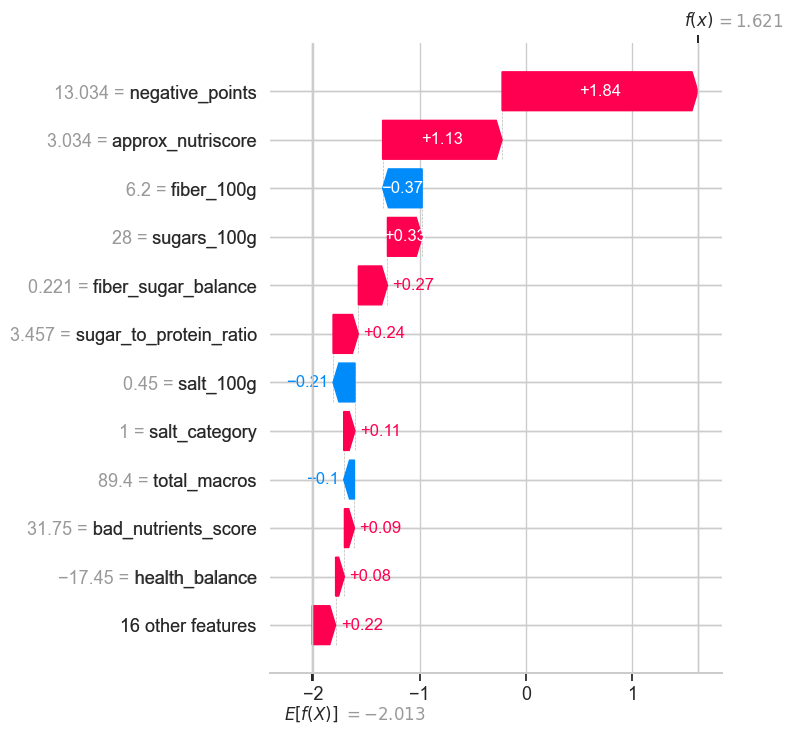

In [ ]:
# waterfall 
sample_pos = 0
pred_class = best_model.predict(X_sample.iloc[[sample_pos]])[0]
print(f'Product 0 → predicted grade {GRADE_LABELS[pred_class]}')

shap.plots.waterfall(
    shap_values[sample_pos, :, pred_class],  # ← slice sur sample + classe
    max_display=12,
    show=False
)
plt.tight_layout()
plt.savefig('plots/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Save & Summary

In [ ]:
joblib.dump(best_model,'models/nutriscore_model.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')
print('Saved:')
print('models/nutriscore_model.pkl')
print('models/feature_names.pkl')

Saved:
models/nutriscore_model.pkl
 models/scaler.pkl
models/feature_names.pkl


In [39]:
print("=" * 62)
print("  NOTEBOOK 2 — MODELING CONCLUSIONS")
print("=" * 62)
cv_gap = abs(cv_f1 - f1_best)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
min_recall= cm_norm.diagonal().min()
min_grade = GRADE_LABELS[cm_norm.diagonal().argmin()]
best_recall= cm_norm.diagonal().max()
best_grade = GRADE_LABELS[cm_norm.diagonal().argmax()]
grade_counts = df[TARGET].value_counts()

print(f"""NOTE : Unlike the EDA which worked on a 50K row random
    sample, this notebook loads the FULL Open Food Facts dataset
    using chunk-based loading then applies stratified sampling
    (5,000 per grade) based on the EDA findings this method gives us
    a better, more balanced dataset for training""") 

print("=" * 62)
print(" 1. DATASET")
print("=" * 62)
print(f"""
 Final dataset : {len(df):,} rows with {df[TARGET].nunique()} classes (perfectly balanced)
 Train  : {X_train.shape[0]:,} samples (80%)
 Test  : {X_test.shape[0]:,} samples (20%)
 Features used : {X_train.shape[1]} (selected from 95+ columns)
""")

print("=" * 62)
print("2. PREPROCESSING")
print("=" * 62)
print(f"""
  We followed the decisions taken in the EDA exactly :
   - Dropped {len(cols_to_drop)} fully empty columns (100% NaN => no information)
   - Fixed physically impossible values (exp fat > 100g/100g)
     => {n_fixed} values replaced with NaN
   - Global median imputation on {X_train.shape[0] + X_test.shape[0]:,} rows
     => 1,618,086 missing values filled in seconds
   - No IQR capping (confirmed by EDA : would destroy signal)
   - nutriscore_score excluded (data leakage)
""")
print("=" * 62)
print("3. FEATURE ENGINEERING")
print("=" * 62)
print(f"""
 We created {len(engineered_features)} engineered features in 4 families :
   ratios, composite scores, NutriScore approximation, and bins.
   Our most important feature — approx_nutriscore — was built
   from scratch using the official Santé Publique France formula instead of using nutriscore_score directly (which would be
 data leakage which it's the answer, not a feature)
   It reaches a correlation of {df['approx_nutriscore'].corr(df[TARGET]):.4f} with the target,
   far stronger than any individual raw column.

   approx_nutriscore by grade :
""")
for k, v in df.groupby(TARGET)['approx_nutriscore'].mean().items():
    sign = '+' if v >= 0 else ''
    print(f" Grade {GRADE_LABELS[k]} : {sign}{v:6.3f} ")
print("=" * 62)
print("4. MODEL PERFORMANCE")
print("=" * 62)
print(f"""
We trained 3 models representing different learning approaches :
   Logistic Regression : F1-Macro = {f1_lr:.4f}  (linear baseline)
   Random Forest : F1-Macro = {f1_rf:.4f}  (ensemble bagging)
   XGBoost : F1-Macro = {f1_xgb:.4f}  (ensemble boosting)
   Tuned XGBoost : F1-Macro = {f1_best:.4f}  (after optimization)
The +{(f1_best - f1_lr)*100:.1f}% gain over Logistic Regression confirms that
NutriScore prediction is a non-linear problem so a simple linear
boundary is not enough to separate 5 nutritional grades

Random Forest and XGBoost start equal, but after tuning XGBoost
with RandomizedSearchCV (30 trials, 5-fold CV), it pulls ahead.
We chose XGBoost for tuning because it has more regularization
hyperparameters (reg_alpha, reg_lambda, min_child_weight) to directly control overfitting   

""")
print("=" * 62)
print("5. ROBUSTNESS & OVERFITTING CHECK")
print("=" * 62)
print(f"""
 5-Fold CV F1-Macro : {cv_f1:.4f} ± {cv_std:.4f}
 Test F1-Macro : {f1_best:.4f}
 Gap CV / Test: {cv_gap:.4f} → {"No overfitting" if cv_gap < 0.03 else " Monitor"}

 The gap is small and the standard deviation is low, meaning
 the model performs consistently across all folds —it's not
 just getting lucky on one particular split.

""")
print("=" * 62)
print("6. ERROR ANALYSIS")
print("=" * 62)
print(f"""
 Recall per class :
   Best  => Grade {best_grade} : {best_recall*100:.1f}% correctly classified
   Worst => Grade {min_grade} : {min_recall*100:.1f}% correctly classified

 The most common errors are between adjacent grades (A↔B, B↔C,
 D↔E)and this is expected because Grade B is nutritionally very close to both
 Grade A and Grade C have very similar But The model never confuses
 grade A with grade E, which would be a serious problem

""")  
print("=" * 62)
print("7. INTERPRETABILITY — SHAP")
print("=" * 62)
print(f"""
  SHAP values confirm the model is learning from nutritionally
 meaningful signals like approx_nutriscore, negative_points and
 salt_100g drive most predictions. Our engineered features
 appear in the top positions, validating that the Feature
 Engineering step added real value beyond raw columns

""")  


  NOTEBOOK 2 — MODELING CONCLUSIONS
NOTE : Unlike the EDA which worked on a 50K row random
    sample, this notebook loads the FULL Open Food Facts dataset
    using chunk-based loading then applies stratified sampling
    (5,000 per grade) based on the EDA findings this method gives us
    a better, more balanced dataset for training
 1. DATASET

 Final dataset : 25,000 rows with 5 classes (perfectly balanced)
 Train  : 20,000 samples (80%)
 Test  : 5,000 samples (20%)
 Features used : 27 (selected from 95+ columns)

2. PREPROCESSING

  We followed the decisions taken in the EDA exactly :
   - Dropped 29 fully empty columns (100% NaN => no information)
   - Fixed physically impossible values (exp fat > 100g/100g)
     => 541 values replaced with NaN
   - Global median imputation on 25,000 rows
     => 1,618,086 missing values filled in seconds
   - No IQR capping (confirmed by EDA : would destroy signal)
   - nutriscore_score excluded (data leakage)

3. FEATURE ENGINEERING

 We create